# **Visualización de datos actividad 2**

### Sebastián Alfonso Pérez Albor

### **Líbrerias y modulos necesarios**

In [537]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json
import geopandas as gpd
from IPython.display import display

### **Conjunto de datos**

In [538]:
datatype = {
    'ANIO_PRECIO': 'object',
    'MES_PRECIO' : 'object',
    'DIA_PRECIO' : 'object',
    'CODIGO_MUNICIPIO_DANE' : 'object',
}
correccion_nombres = {
    'SANTANDER' : 'SANTANDER',
    'CUNDINAMARCA': 'CUNDINAMARCA',
    'CALDAS' : 'CALDAS',
    'BOGOTA D.C.' : 'SANTAFE DE BOGOTA D.C',
    'VALLE DEL CAUCA': 'VALLE DEL CAUCA',
    'RISARALDA' : 'RISARALDA',
    'ATLANTICO': 'ATLANTICO',
    'TOLIMA': 'TOLIMA',
    'ANTIOQUIA': 'ANTIOQUIA',
    'QUINDIO': 'QUINDIO',
}

In [539]:
df = pd.read_csv("PreciosGasNaturalVehicula.csv", sep = ',', dtype = datatype)
df['DEPARTAMENTO_EDS'] = df['DEPARTAMENTO_EDS'].replace(correccion_nombres)
df['FECHA_PRECIO'] = pd.to_datetime(df['FECHA_PRECIO'], format='%Y-%m-%d')
df.head(n = 10)

,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
0,2024-09-01,2024,09,01,SANTANDER,BUCARAMANGA,CAMOVA,2299,GNCV,68001,7.155834,-73.111572
1,2024-07-01,2024,07,01,SANTANDER,BUCARAMANGA,CAMOVA,2249,GNCV,68001,7.155834,-73.111572
2,2024-10-01,2024,10,01,CUNDINAMARCA,CHIA,CHIA EDS - GNV,2787,GNCV,25175,4.857824,-74.038094
3,2024-10-01,2024,10,01,CALDAS,MANIZALES,ESTACIÓN DE SERVICIO CALDAS,3324,GNCV,17001,5.083433,-75.507278
4,2024-10-01,2024,10,01,SANTAFE DE BOGOTA D.C,"BOGOTA, D.C.",ESTACION DE SERVICIO COMBUSCOL EL DORADO,2718,GNCV,11001,4.652954,-74.083565
5,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIOS LAS CEIBAS CALI S.A.S.,3336,GNCV,76001,3.399044,-76.576492
6,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO TERPEL CAÑAVERALEJO - GNV,3367,GNCV,76001,3.399044,-76.576492
7,2024-10-01,2024,10,01,RISARALDA,PEREIRA,EDS SANTA HELENA,2869,GNCV,66001,4.803663,-75.795792
8,2024-10-01,2024,10,01,SANTAFE DE BOGOTA D.C,"BOGOTA, D.C.",ESTACION DE SERVICIO COMBUSCOL HEROES,2717,GNCV,11001,4.652954,-74.083565
9,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO AUTOMOTRIZ GUADUALES GNV,3367,GNCV,76001,3.399044,-76.576492


### **Análisis general del conjunto de datos**

In [540]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9863 entries, 0 to 9862
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   FECHA_PRECIO               9863 non-null   datetime64[ns]
 1   ANIO_PRECIO                9863 non-null   object        
 2   MES_PRECIO                 9863 non-null   object        
 3   DIA_PRECIO                 9863 non-null   object        
 4   DEPARTAMENTO_EDS           9863 non-null   object        
 5   MUNICIPIO_EDS              9863 non-null   object        
 6   NOMBRE_COMERCIAL_EDS       9863 non-null   object        
 7   PRECIO_PROMEDIO_PUBLICADO  9863 non-null   int64         
 8   TIPO_COMBUSTIBLE           9863 non-null   object        
 9   CODIGO_MUNICIPIO_DANE      9863 non-null   object        
 10  LATITUD_MUNICIPIO          9863 non-null   float64       
 11  LONGITUD_MUNICIPIO         9863 non-null   float64       
dtypes: dat

Como se puede observar ninguna variable presenta datos faltantes

In [541]:
df['TIPO_COMBUSTIBLE'].unique()

array(['GNCV'], dtype=object)

In [542]:
df['DEPARTAMENTO_EDS'].unique()

array(['SANTANDER', 'CUNDINAMARCA', 'CALDAS', 'SANTAFE DE BOGOTA D.C',
       'VALLE DEL CAUCA', 'RISARALDA', 'ATLANTICO', 'TOLIMA', 'ANTIOQUIA',
       'QUINDIO', 'MAGDALENA', 'CAUCA', 'BOLIVAR', 'CESAR', 'META',
       'SUCRE', 'CORDOBA', 'BOYACA', 'CASANARE', 'HUILA', 'CAQUETA',
       'LA GUAJIRA'], dtype=object)

In [543]:
df['DEPARTAMENTO_EDS'].nunique()

22

El dataset solo contiene información de 22 de los 33 departamentos de Colombia.

In [578]:
df['MUNICIPIO_EDS'].unique()

array(['BUCARAMANGA', 'CHIA', 'MANIZALES', 'BOGOTA, D.C.', 'CALI',
       'PEREIRA', 'BARRANQUILLA', 'PALMIRA', 'IBAGUE', 'MEDELLIN',
       'CALARCA', 'ARMENIA', 'SANTA MARTA', 'POPAYAN',
       'CARTAGENA DE INDIAS', 'BELLO', 'VALLEDUPAR', 'TULUA', 'BARBOSA',
       'BOSCONIA', 'MOSQUERA', 'MALAMBO', 'PUERTO COLOMBIA', 'CUMARAL',
       'COROZAL', 'COTA', 'PLANETA RICA', 'SOACHA', 'SOPO', 'YUMBO',
       'PIEDECUESTA', 'DUITAMA', 'APARTADO', 'CHIQUINQUIRA', 'SABANETA',
       'RIONEGRO', 'YOPAL', 'SOGAMOSO', 'SAHAGUN', 'MONTERIA', 'SOLEDAD',
       'JAMUNDI', 'BARRANCABERMEJA', 'SOTAQUIRA', 'ITAGUI',
       'VILLAVICENCIO', 'CARTAGO', 'TUNJA', 'CIENAGA', 'DOSQUEBRADAS',
       'GIRON', 'NEIVA', 'SINCELEJO', 'LA DORADA', 'ENVIGADO',
       'FACATATIVA', 'PAILITAS', 'FLORIDABLANCA', 'AGUAZUL', 'ARMERO',
       'ESPINAL', 'GUADALAJARA DE BUGA', 'SANTANDER DE QUILICHAO',
       'FLORENCIA', 'VENADILLO', 'GIRARDOT', 'LA UNION', 'BUENAVENTURA',
       'LA MESA', 'FUNZA', 'GUARNE', 'TURBACO

In [579]:
df['MUNICIPIO_EDS'].nunique()

86

In [545]:
df.groupby('DEPARTAMENTO_EDS')['MUNICIPIO_EDS'].unique()

DEPARTAMENTO_EDS
ANTIOQUIA                [MEDELLIN, BELLO, APARTADO, SABANETA, RIONEGRO...
ATLANTICO                [BARRANQUILLA, MALAMBO, PUERTO COLOMBIA, SOLEDAD]
BOLIVAR                           [CARTAGENA DE INDIAS, TURBACO, MAGANGUE]
BOYACA                   [DUITAMA, CHIQUINQUIRA, SOGAMOSO, SOTAQUIRA, T...
CALDAS                                   [MANIZALES, LA DORADA, CHINCHINA]
CAQUETA                                                        [FLORENCIA]
CASANARE                                  [YOPAL, AGUAZUL, PAZ DE ARIPORO]
CAUCA                                    [POPAYAN, SANTANDER DE QUILICHAO]
CESAR                          [VALLEDUPAR, BOSCONIA, PAILITAS, AGUACHICA]
CORDOBA                                  [PLANETA RICA, SAHAGUN, MONTERIA]
CUNDINAMARCA             [CHIA, MOSQUERA, COTA, SOACHA, SOPO, FACATATIV...
HUILA                                                              [NEIVA]
LA GUAJIRA                                                      [RIOHACHA]
MAGDALEN

In [ ]:
df.groupby('DEPARTAMENTO_EDS')['MUNICIPIO_EDS'].nunique().sort_values(ascending=False)

DEPARTAMENTO_EDS
VALLE DEL CAUCA          12
CUNDINAMARCA             11
ANTIOQUIA                10
SANTANDER                 7
BOYACA                    5
TOLIMA                    4
CESAR                     4
ATLANTICO                 4
CASANARE                  3
CORDOBA                   3
BOLIVAR                   3
CALDAS                    3
MAGDALENA                 3
SUCRE                     3
CAUCA                     2
META                      2
QUINDIO                   2
RISARALDA                 2
LA GUAJIRA                1
SANTAFE DE BOGOTA D.C     1
CAQUETA                   1
HUILA                     1
Name: MUNICIPIO_EDS, dtype: int64

El dataset contiene información sobre 86 municipios de Colombia, de los cuales 12 pertenecen al departamento del Valle del Cauca como lo son: CALI, PALMIRA, TULUA, YUMBO, JAMUNDI, etc. 11 de Cundinamarca: CHIA, MOSQUERA, COTA, SOACHA, etc. En el departamento de Antioquia encontramos 10 departamentos y en el Atlántico 4 que son: BARRANQUILLA, MALAMBO, PUERTO COLOMBIA, SOLEDAD.

In [549]:
df['DIA_PRECIO'].unique()

array(['01'], dtype=object)

##### **Eliminación de Varibles innecesarias**

In [ ]:
df = df.drop(columns = ['DIA_PRECIO ', ' NOMBRE_COMERCIAL_EDS', 
                        'TIPO_COMBUSTIBLE', 'CODIGO_MUNICIPIO_DANE',
                          'LATITUD_MUNICIPIO', 'LONGITUD_MUNICIPIO' ]
            )

| **Variable**              | **Motivo de Eliminación**                                                   |
|----------------------------|----------------------------------------------------------------------------|
| DIA_PRECIO                 | Todos los valores son "1", por lo que no aporta información relevante al análisis. |
| NOMBRE_COMERCIAL_EDS       | El nombre comercial de la estación no es necesario para el análisis a nivel de municipio o departamento. |
| TIPO_COMBUSTIBLE           | El análisis se enfoca únicamente en el precio promedio del gas natural comprimido (GNCV). |
| CODIGO_MUNICIPIO_DANE      | Para la visualización en el mapa se utilizará el nombre del municipio, no su código. |
| LATITUD_MUNICIPIO          | La información geoespacial no es necesaria, ya que los nombres de municipios serán utilizados en el análisis. |
| LONGITUD_MUNICIPIO         | Similar a la latitud, esta variable no será usada para el análisis geográfico. |

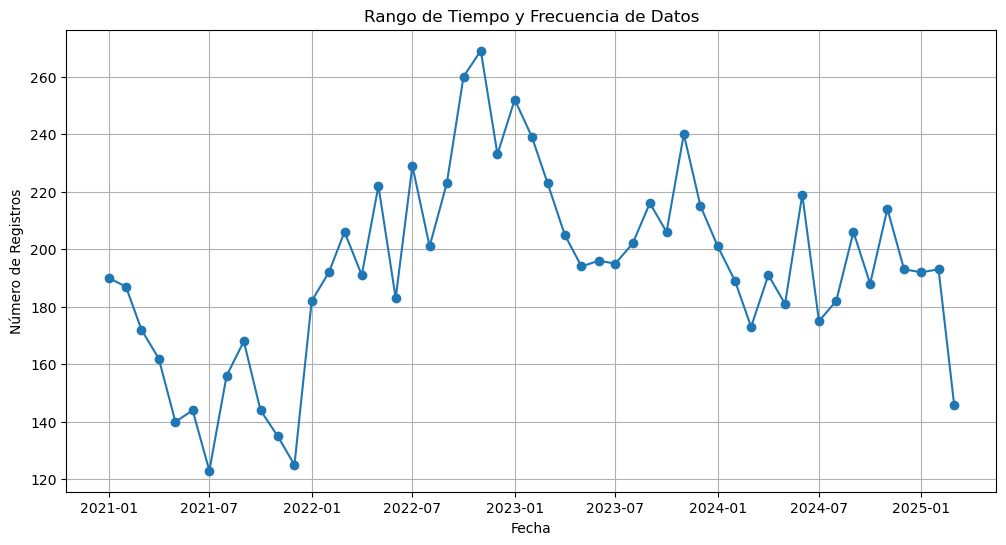

In [ ]:
conteo_fechas = df['FECHA_PRECIO'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(conteo_fechas.index, conteo_fechas.values, marker = 'o', linestyle = '-')
plt.title('Rango de Tiempo y Frecuencia de Datos')
plt.xlabel('Fecha')
plt.ylabel('Número de Registros')
plt.grid(True)
plt.show()

In [551]:
df_2021 = df.query("FECHA_PRECIO.dt.year == 2021")
df_2022 = df.query("FECHA_PRECIO.dt.year == 2022")
df_2023 = df.query("FECHA_PRECIO.dt.year == 2023")
df_2024 = df.query("FECHA_PRECIO.dt.year == 2024")
df_2025 = df.query("FECHA_PRECIO.dt.year == 2025")

In [552]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [553]:
resultado = df_2021.groupby(['DEPARTAMENTO_EDS', 'MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

# Obtener el índice del máximo valor y el valor máximo
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index
resultado

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS      MUNICIPIO_EDS                                 
ANTIOQUIA             APARTADO                               1811.00
                      BELLO                                  1794.06
                      ITAGUI                                 1793.00
                      MEDELLIN                               1808.33
                      RIONEGRO                               1870.32
                      SABANETA                               1815.00
ATLANTICO             BARRANQUILLA                           1559.55
                      PUERTO COLOMBIA                        1595.42
                      SOLEDAD                                1573.17
BOLIVAR               CARTAGENA DE INDIAS                    1648.55
                      MAGANGUE                               1549.00
                      TURBACO                                1677.00
BOYACA                CHIQUINQUIRA                           1228.43
                      DUITAMA                                1690.00
                      SOGAMOSO                               1264.00
                      TUNJA                                  1626.93
CALDAS                CHINCHINA                              1990.00
                      MANIZALES                              1961.06
CASANARE              YOPAL                                  1762.50
CAUCA                 POPAYAN                                2050.57
CESAR                 BOSCONIA                               1581.73
                      VALLEDUPAR                             1353.09
CORDOBA               MONTERIA                               1745.26
                      PLANETA RICA                           1649.00
                      SAHAGUN                                1549.00
CUNDINAMARCA          CHIA                                   1736.09
                      COTA                                   1780.88
                      FACATATIVA                             1809.00
                      FUNZA                                  1809.00
                      MOSQUERA                               1810.80
                      SOACHA                                 1700.50
                      SOPO                                   1832.33
HUILA                 NEIVA                                  1945.50
MAGDALENA             SANTA MARTA                            1646.00
META                  CUMARAL                                1589.00
                      VILLAVICENCIO                          1690.00
QUINDIO               ARMENIA                                2074.00
                      CALARCA                                2074.00
RISARALDA             DOSQUEBRADAS                           1784.59
                      PEREIRA                                1792.00
SANTAFE DE BOGOTA D.C BOGOTA, D.C.                           1708.31
SANTANDER             BARBOSA                                1763.50
                      BUCARAMANGA                            1687.00
                      FLORIDABLANCA                          1747.20
                      GIRON                                  1651.09
                      LEBRIJA                                1799.00
SUCRE                 COROZAL                                1839.00
                      SINCELEJO                              1619.92
TOLIMA                IBAGUE                                 1743.72
                      VENADILLO                              1850.00
VALLE DEL CAUCA       BUENAVENTURA                           1987.00
                      CALI                                   1787.48
                      CARTAGO                                2040.00
                      FLORIDA                                1980.00
                      GUADALAJARA DE BUGA                    1627.00
                      JAMUNDI                                1810.00
                      LA UNION           

In [554]:
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

print(f"Departamento: {departamento_maximo}")
print(f"Municipio: {municipio_maximo}")
print(f"Precio Promedio Máximo: {max_value}")

Departamento: QUINDIO
Municipio: ARMENIA
Precio Promedio Máximo: 2074.0


In [555]:
resultado = df_2022.groupby(['DEPARTAMENTO_EDS', 'MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

# Obtener el índice del máximo valor y el valor máximo
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index
resultado

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS      MUNICIPIO_EDS                                    
ANTIOQUIA             APARTADO                                  2020.00
                      BARBOSA                                   2066.25
                      BELLO                                     2059.37
                      ENVIGADO                                  2251.67
                      ITAGUI                                    2178.77
                      MEDELLIN                                  2107.30
                      RIONEGRO                                  2083.36
                      SABANETA                                  2049.17
ATLANTICO             BARRANQUILLA                              1724.47
                      MALAMBO                                   1789.83
                      PUERTO COLOMBIA                           1715.00
                      SOLEDAD                                   1721.48
BOLIVAR               CARTAGENA DE INDIAS                       1764.23
                      TURBACO                                   1759.90
BOYACA                CHIQUINQUIRA                              1889.00
                      DUITAMA                                   1837.27
                      SOGAMOSO                                  1748.00
                      TUNJA                                     1832.62
CALDAS                CHINCHINA                                 2386.67
                      LA DORADA                                 1813.20
                      MANIZALES                                 2203.76
CAQUETA               FLORENCIA                                 2200.00
CASANARE              YOPAL                                     1795.00
CAUCA                 POPAYAN                                   2384.18
                      SANTANDER DE QUILICHAO                    2871.00
CESAR                 BOSCONIA                                  1741.00
                      VALLEDUPAR                                1490.90
CORDOBA               MONTERIA                                  1834.22
                      PLANETA RICA                              1796.75
                      SAHAGUN                                   1959.33
CUNDINAMARCA          CHIA                                      1917.00
                      COTA                                      1822.13
                      FUNZA                                     1972.33
                      FUSAGASUGA                                1869.00
                      GIRARDOT                                  2394.00
                      MOSQUERA                                  1976.61
                      SOACHA                                    1873.08
                      SOPO                                      1967.18
HUILA                 NEIVA                                     2218.09
MAGDALENA             SANTA MARTA                               1794.13
META                  CUMARAL                                   1779.00
                      VILLAVICENCIO                             1865.77
QUINDIO               ARMENIA                                   2315.16
                      CALARCA                                   2298.17
RISARALDA             DOSQUEBRADAS                              2057.83
                      PEREIRA                                   2032.64
SANTAFE DE BOGOTA D.C BOGOTA, D.C.                              1832.01
SANTANDER             BARBOSA                                   1967.04
                      BUCARAMANGA                               2088.75
                      FLORIDABLANCA                             2243.50
                      GIRON                                     2117.45
SUCRE                 COROZAL                                   1973.75
                      SAN PEDRO                                 1699.00
                      SINCELEJO                                 1845.84
TOLIMA        

In [556]:
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

print(f"Departamento: {departamento_maximo}")
print(f"Municipio: {municipio_maximo}")
print(f"Precio Promedio Máximo: {max_value}")

Departamento: CAUCA
Municipio: SANTANDER DE QUILICHAO
Precio Promedio Máximo: 2871.0


In [557]:
resultado = df_2023.groupby(['DEPARTAMENTO_EDS', 'MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

# Obtener el índice del máximo valor y el valor máximo
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

In [558]:
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

print(f"Departamento: {departamento_maximo}")
print(f"Municipio: {municipio_maximo}")
print(f"Precio Promedio Máximo: {max_value}")

Departamento: VALLE DEL CAUCA
Municipio: FLORIDA
Precio Promedio Máximo: 5885.0


In [559]:
resultado = df_2024.groupby(['DEPARTAMENTO_EDS', 'MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

# Obtener el índice del máximo valor y el valor máximo
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

In [560]:
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

print(f"Departamento: {departamento_maximo}")
print(f"Municipio: {municipio_maximo}")
print(f"Precio Promedio Máximo: {max_value}")

Departamento: CAUCA
Municipio: POPAYAN
Precio Promedio Máximo: 3383.4


In [561]:
resultado = df_2025.groupby(['DEPARTAMENTO_EDS', 'MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

# Obtener el índice del máximo valor y el valor máximo
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

In [562]:
max_index = resultado['PRECIO_PROMEDIO_PUBLICADO'].idxmax()
max_value = resultado['PRECIO_PROMEDIO_PUBLICADO'].max()

departamento_maximo, municipio_maximo = max_index

print(f"Departamento: {departamento_maximo}")
print(f"Municipio: {municipio_maximo}")
print(f"Precio Promedio Máximo: {max_value}")

Departamento: ANTIOQUIA
Municipio: BARBOSA
Precio Promedio Máximo: 3990.0


In [564]:
geojson_url = 'https://raw.githubusercontent.com/lihkir/Uninorte/main/AppliedStatisticMS/DataVisualizationRPython/Lectures/Python/PythonDataSets/Colombia.geo.json'
colombia_geo = gpd.read_file(geojson_url)
colombia_geo['NOMBRE_DPT'] = colombia_geo['NOMBRE_DPT'].str.upper()

def graficar_precios_por_departamento(df, year):
    df = df.copy()
    df['DEPARTAMENTO_EDS'] = df['DEPARTAMENTO_EDS'].str.upper()

    precios_mapa = df.groupby('DEPARTAMENTO_EDS')['PRECIO_PROMEDIO_PUBLICADO'].mean().round(2).reset_index()
    merged = colombia_geo.merge(precios_mapa, left_on='NOMBRE_DPT', right_on='DEPARTAMENTO_EDS', how='left')
    merged['PRECIO_PROMEDIO_PUBLICADO'] = merged['PRECIO_PROMEDIO_PUBLICADO'].fillna(0)

    fig, axs = plt.subplots(1, 2, figsize=(18, 8))

    cmap = 'viridis'
    merged.plot(column='PRECIO_PROMEDIO_PUBLICADO',
                 cmap=cmap,
                 linewidth=0.8,
                 edgecolor='0.8',
                 legend=True,
                 ax=axs[0])

    axs[0].set_title(f'Precios Promedio GAS (GNCV) Publicado por Departamento en {year}', fontsize=14)
    axs[0].axis('off')

    for idx, row in merged.iterrows():
        if not pd.isna(row['PRECIO_PROMEDIO_PUBLICADO']):
            axs[0].annotate(text=row['NOMBRE_DPT'], 
                             xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                             fontsize=6, ha='center', color='black')

    df['FECHA_PRECIO'] = pd.to_datetime(df['FECHA_PRECIO'])
    precios_tiempo = df.groupby(['FECHA_PRECIO', 'DEPARTAMENTO_EDS'])['PRECIO_PROMEDIO_PUBLICADO'].mean().reset_index()

    top_10_departamentos = precios_mapa.nlargest(10, 'PRECIO_PROMEDIO_PUBLICADO')['DEPARTAMENTO_EDS']

    for depto in top_10_departamentos:
        data = precios_tiempo[precios_tiempo['DEPARTAMENTO_EDS'] == depto]
        axs[1].plot(data['FECHA_PRECIO'], data['PRECIO_PROMEDIO_PUBLICADO'], label=depto, linewidth=1)

    axs[1].set_title(f'Evolución del Precio Promedio del GAS (GNCV) por Departamento ({year}) - Top 10', fontsize=14)
    axs[1].set_xlabel('Fecha')
    axs[1].set_ylabel('Precio Promedio Publicado')
    axs[1].legend(loc='upper left', fontsize=8, ncol=2)
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


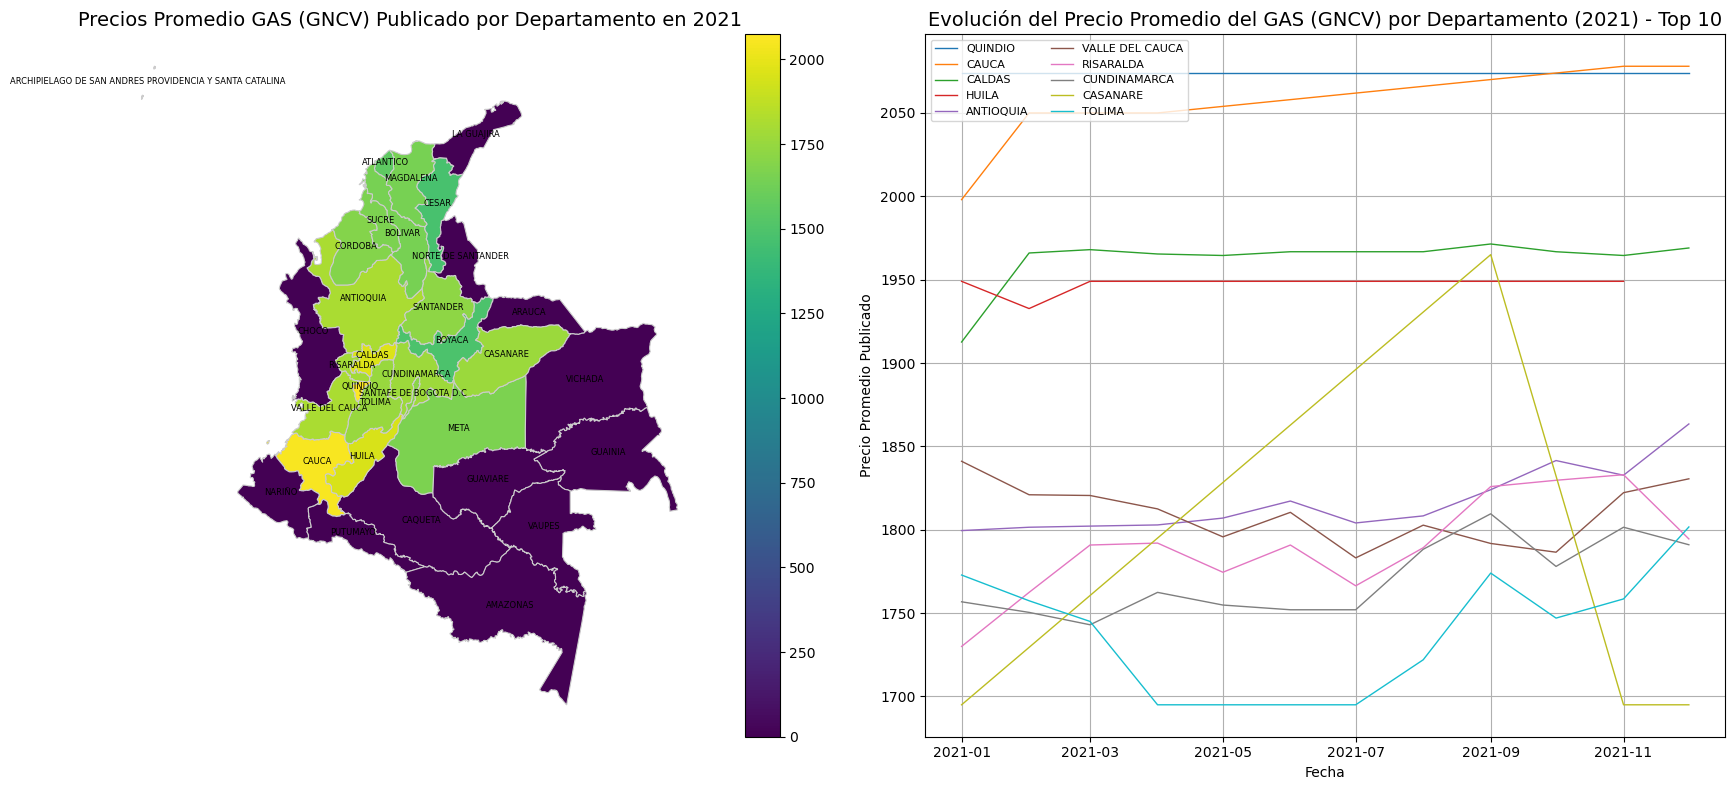

In [565]:
graficar_precios_por_departamento(df_2021, 2021)

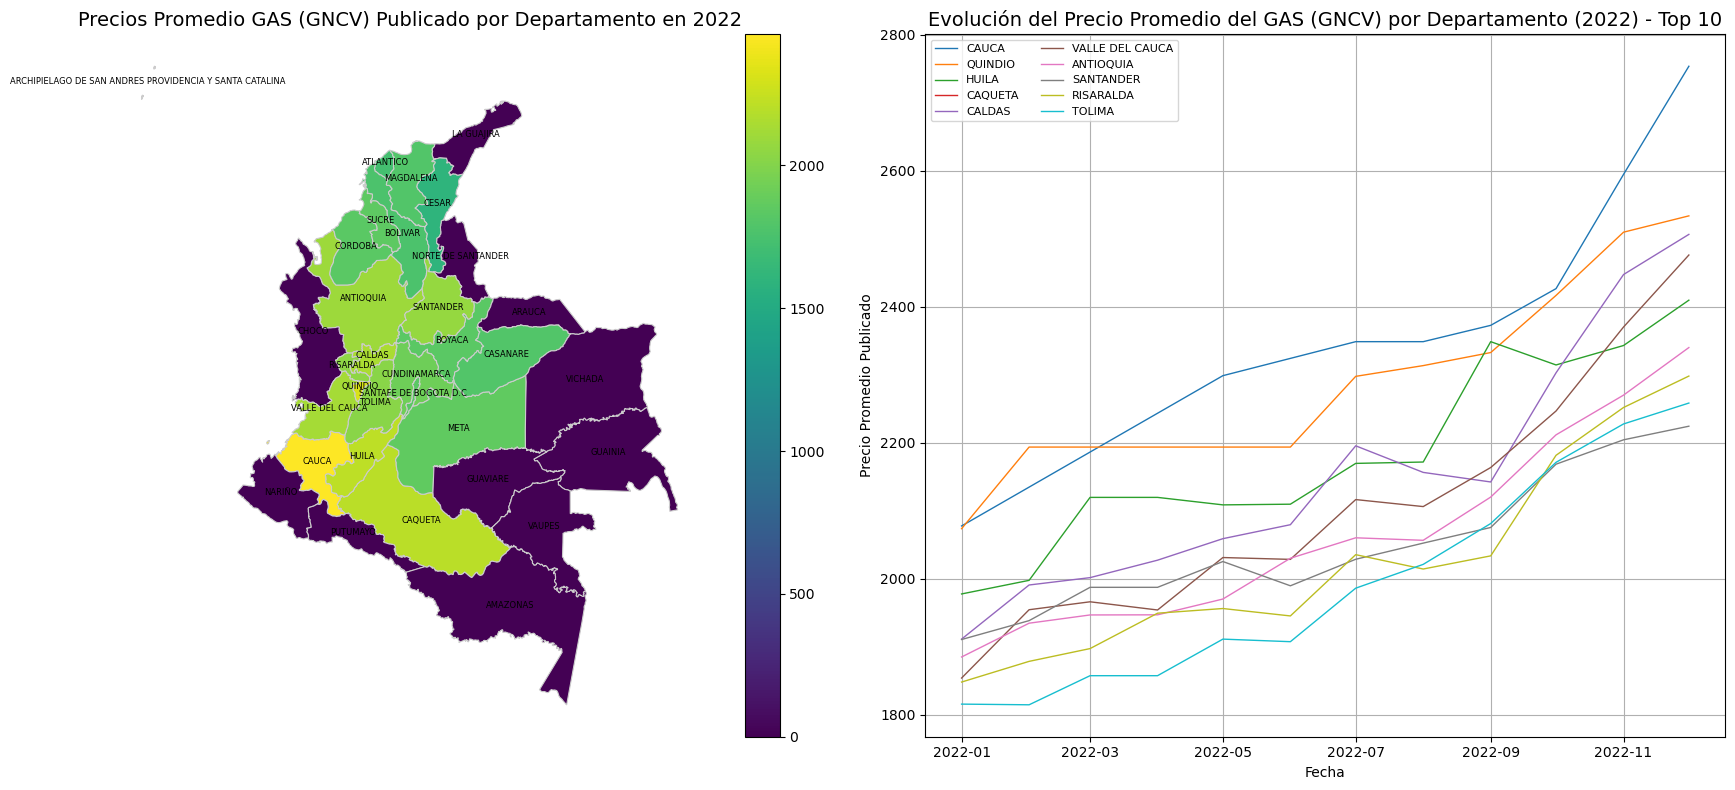

In [566]:
graficar_precios_por_departamento(df_2022, 2022)

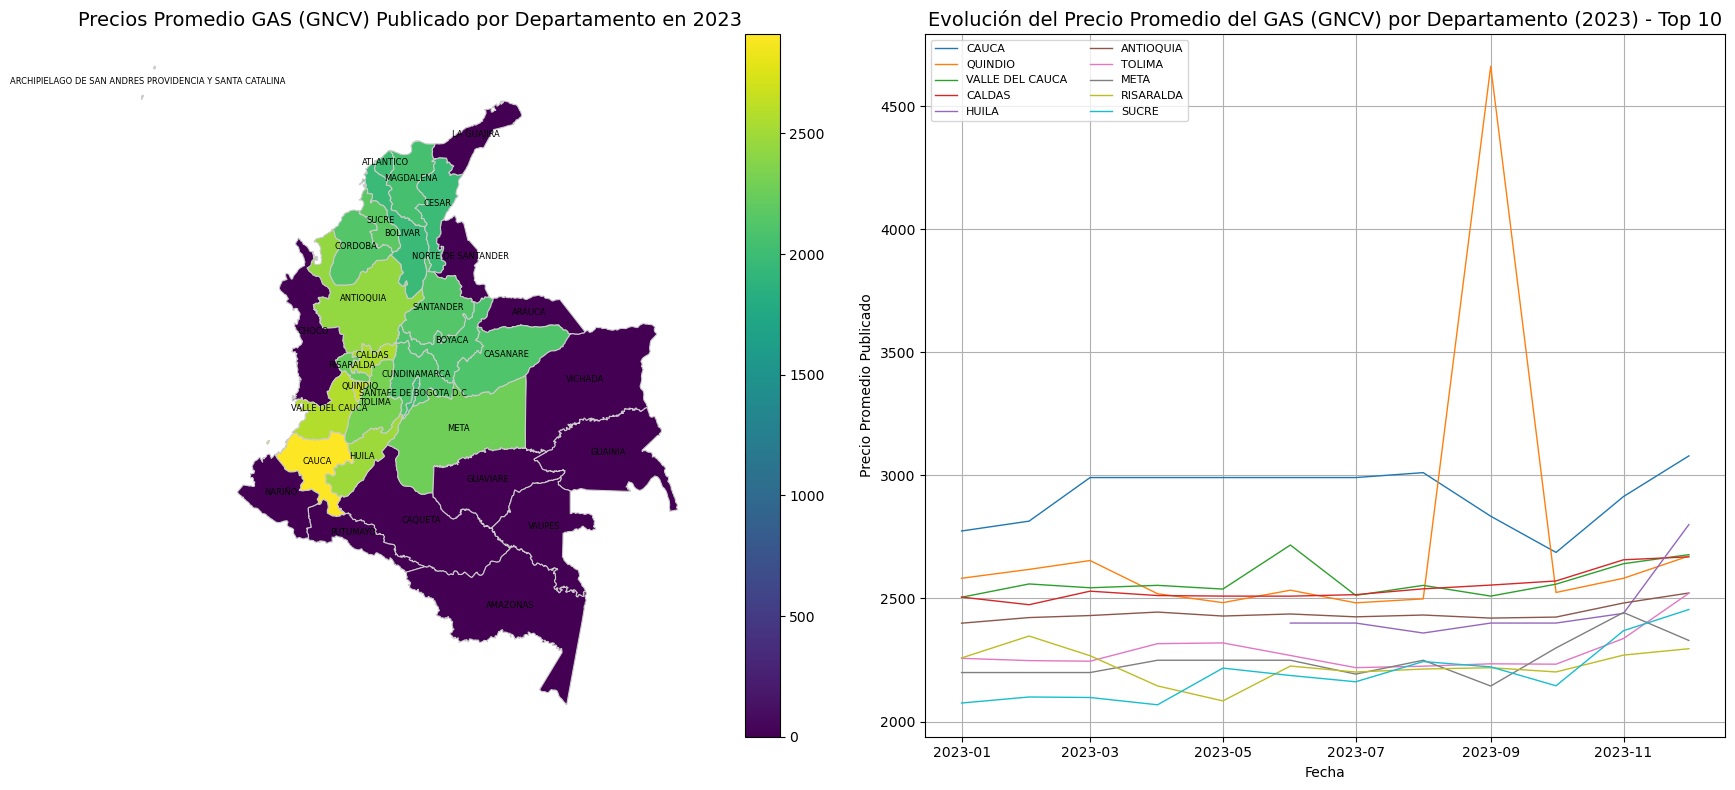

In [567]:
graficar_precios_por_departamento(df_2023, 2023)

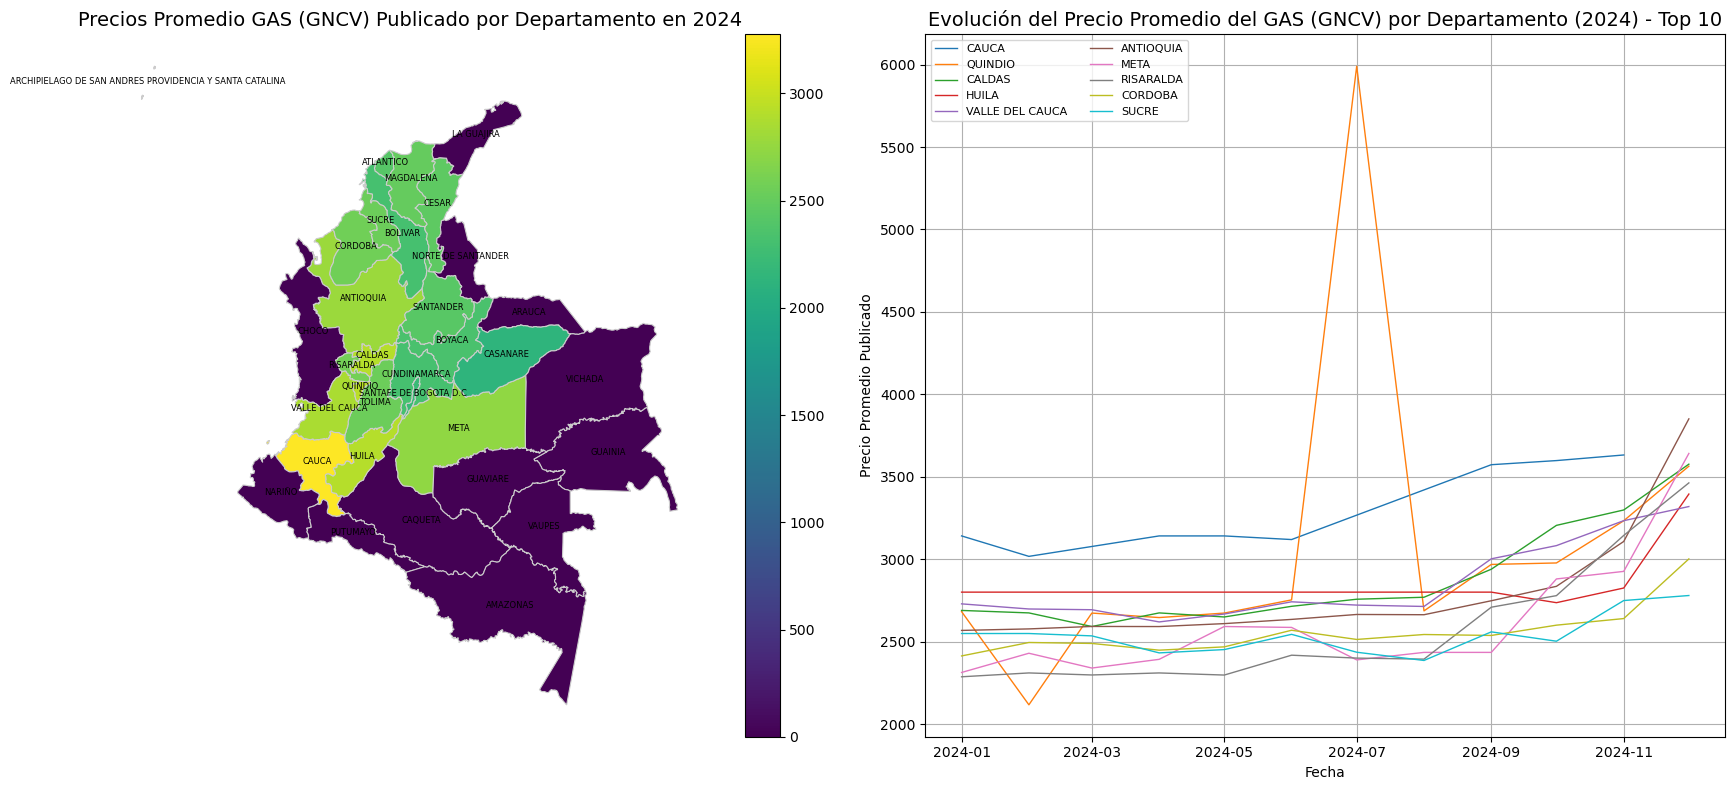

In [568]:
graficar_precios_por_departamento(df_2024, 2024)

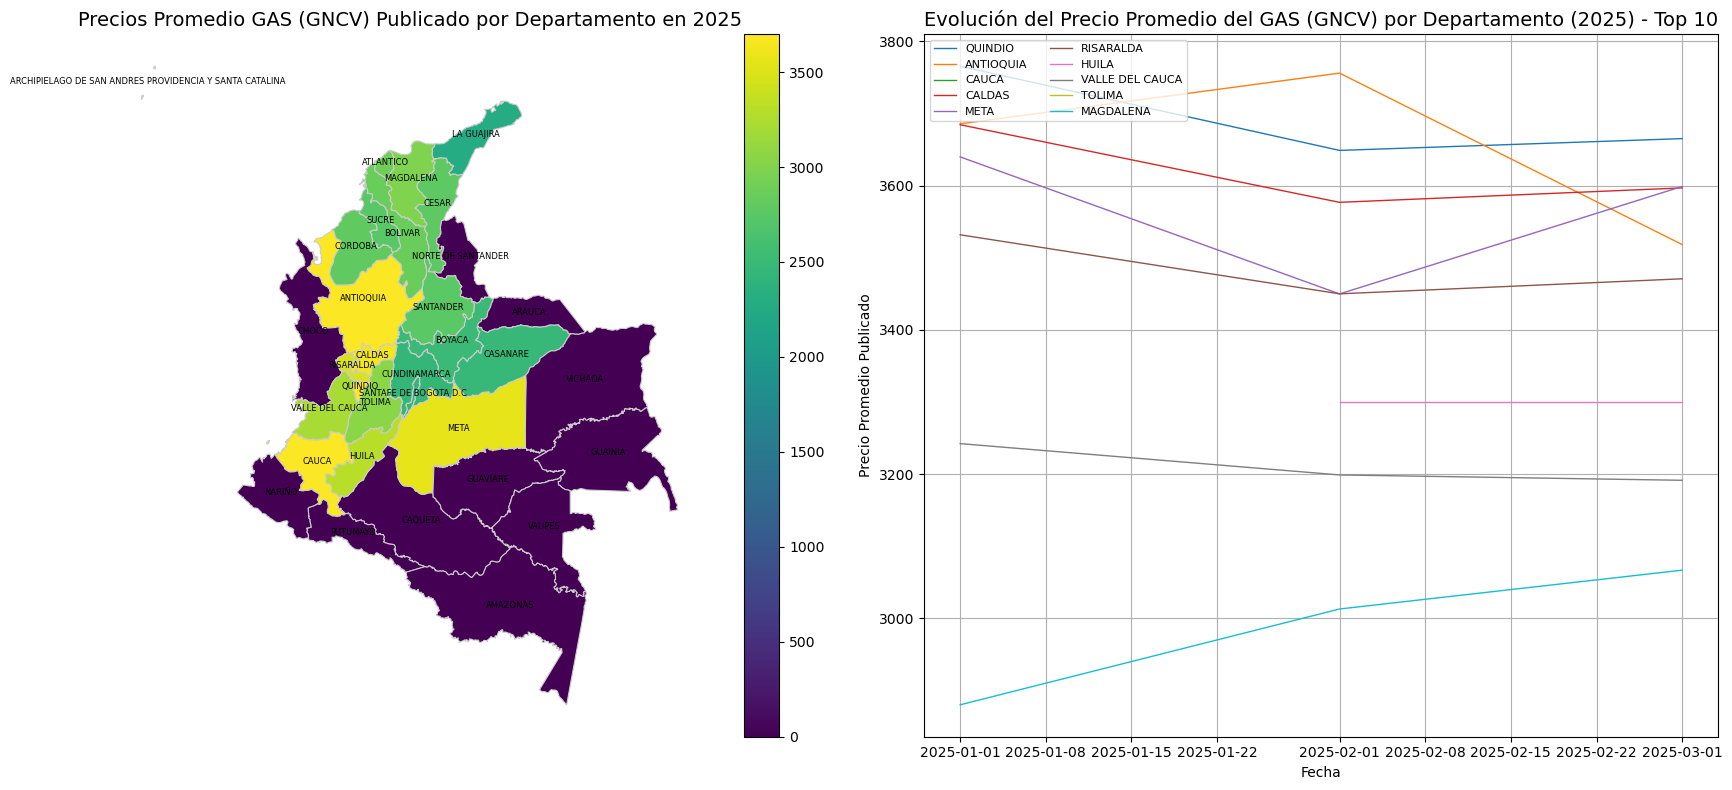

In [569]:
graficar_precios_por_departamento(df_2025, 2025)

In [570]:
def graficar_precio_promedio_por_departamento(df, departamento):
    # Filtrar por departamento
    df_filtrado = df[df['DEPARTAMENTO_EDS'].str.upper() == departamento.upper()].copy()
    
    # Agrupar por fecha y municipio
    df_filtrado = df_filtrado.groupby(['FECHA_PRECIO', 'MUNICIPIO_EDS'])['PRECIO_PROMEDIO_PUBLICADO'].mean().reset_index()

    # Graficar
    plt.figure(figsize=(12, 8))
    for municipio in df_filtrado['MUNICIPIO_EDS'].unique():
        data = df_filtrado[df_filtrado['MUNICIPIO_EDS'] == municipio]
        plt.plot(data['FECHA_PRECIO'], data['PRECIO_PROMEDIO_PUBLICADO'], label=municipio, linewidth=1)

    plt.title(f'Evolución del Precio Promedio en Municipios de {departamento.upper()} (2021-2025)')
    plt.xlabel('Fecha')
    plt.ylabel('Precio Promedio Publicado')
    plt.legend(loc='best', fontsize=8, ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

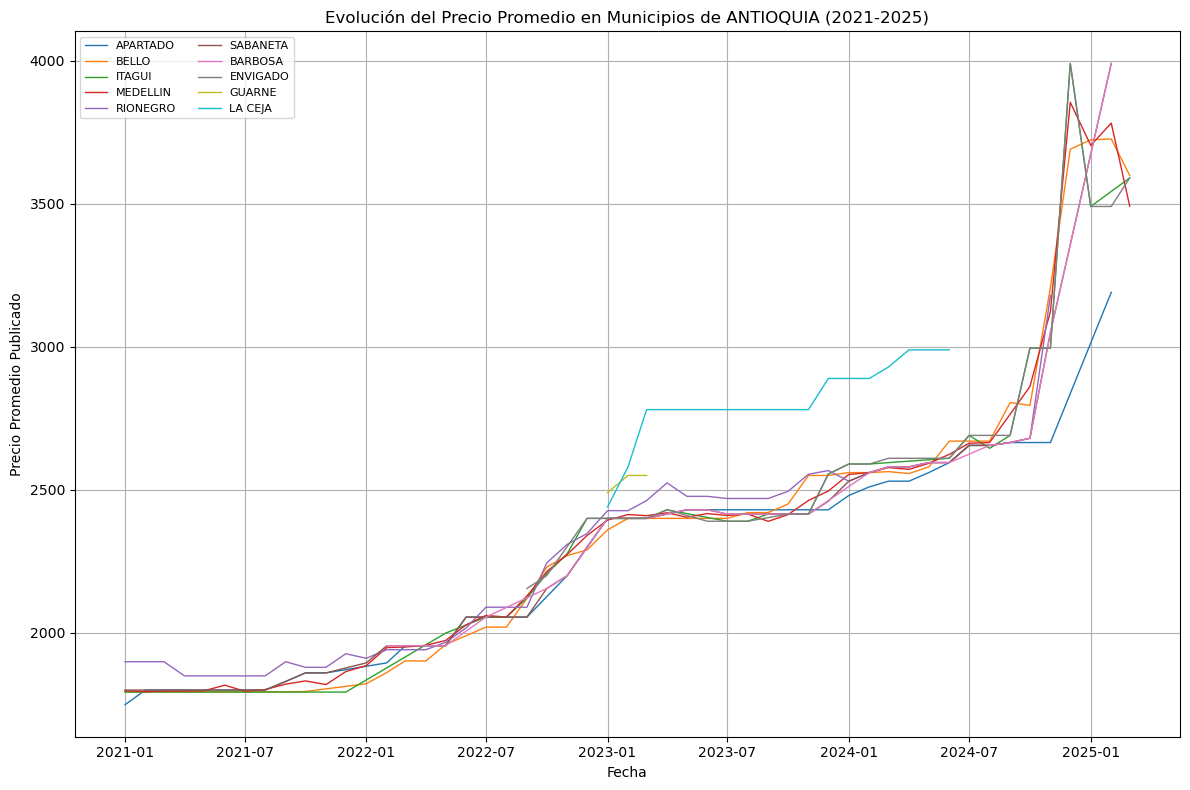

In [571]:
graficar_precio_promedio_por_departamento(df, 'ANTIOQUIA')

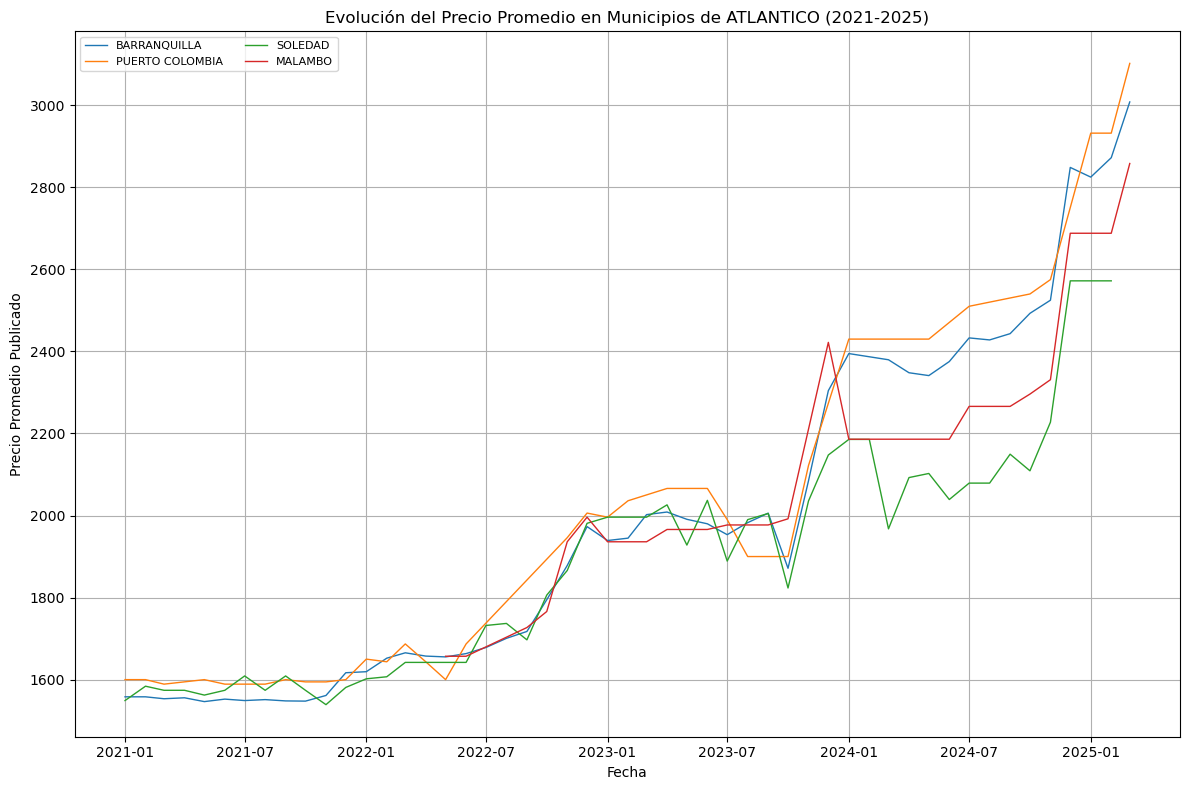

In [572]:
graficar_precio_promedio_por_departamento(df, 'ATLANTICO')

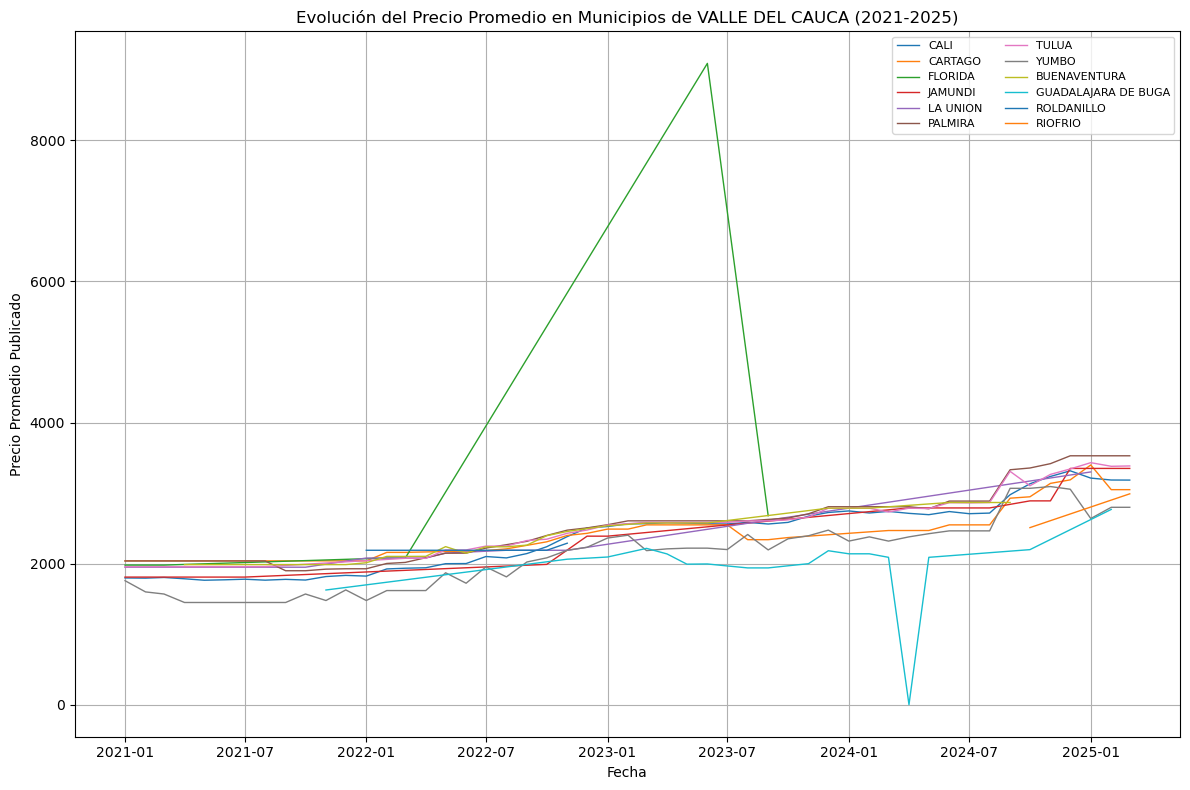

In [573]:
graficar_precio_promedio_por_departamento(df, 'VALLE DEL CAUCA')
